<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    Fraud Graph Analytics - Data Science Project
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                     Domain Understanding com CRISP-DM+
                </strong>
            </font>
        </p>
        <p style="text-align: center;">
            <font size="5" color='#C58A1E'>
                <strong>
                    Predição de inadimplência em cartão de crédito com<br />machine learning e avaliação orientada a negócio
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento [-] Custo [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Mestre Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 1. Contexto de Negócio</strong></font>

<font size="2" color='#66666'>

>- Este notebook inaugura a etapa de **Domain Understanding** do projeto, utilizando uma abordagem baseada em **CRISP-DM+**, enriquecida com:
    - *Ontologia de domínio;*
    - *Business Language Model;*
    - *Taxonomia de fraudes;*
    - *hipóteses investigativas;*
    - *desenho inicial do Knowledge Graph;*
    - *critérios de sucesso do MVP.*

>- O objetivo é construir uma base conceitual sólida antes da geração dos dados sintéticos, da criação das regras antifraude e da modelagem em grafo.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 1. Objetivo</strong></font>

<font size="2" color='#66666'>

>- Definir o escopo inicial do projeto de prevenção a fraudes transacionais, estruturando o entendimento do domínio antes da etapa de geração de dados e modelagem.

>- **Ações realizadas**
    - ***Definição do problema de negócio.***
    - ***Adaptação do CRISP-DM para uma abordagem CRISP-DM+.***
    - ***Mapeamento de entidades relevantes para o domínio de fraude.***
    - ***Construção inicial de uma ontologia operacional.***
    - ***Criação de um Business Language Model.***
    - ***Definição de uma taxonomia de fraudes.***
    - ***Formulação de hipóteses investigativas.***
    - ***Desenho conceitual do Knowledge Graph.***

>- **Justificativa técnica**
    - Projetos de fraude **exigem uma compreensão explícita das relações entre entidades, eventos e comportamentos**.
    - A etapa de *Domain Understanding reduz ambiguidade, melhora a rastreabilidade das decisões analíticas e facilita a transição entre negócio, dados, regras e grafo*.

>- **Resultados esperados**
    - Ao final deste notebook, o projeto terá uma base conceitual documentada, com entidades, relações, hipóteses, taxonomia e critérios de sucesso definidos para orientar os próximos notebooks.

---

</font></div>

In [1]:
from pathlib import Path

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "RobertoSSoares-LfLngLrnng"

Author: RobertoSSoares-LfLngLrnng



In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DOCS_DIR = PROJECT_ROOT / "docs"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

DOCS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Docs dir:     {DOCS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

Project root: D:\_DS-Projects\Data-Science\fraud-graph-analytics
Docs dir:     D:\_DS-Projects\Data-Science\fraud-graph-analytics\docs
Figures dir:  D:\_DS-Projects\Data-Science\fraud-graph-analytics\artifacts\figures


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 2. Contexto de Negócio</strong></font>

<font size="2" color='#66666'>

>- A prevenção a fraudes transacionais é uma disciplina crítica em instituições financeiras, especialmente em operações envolvendo conta corrente, PIX, cartões, transferências e pagamentos digitais.

>- Fraudes transacionais normalmente não aparecem apenas como eventos isolados. Muitas vezes, elas surgem a partir de padrões relacionais e comportamentais, como:
    - *múltiplas contas utilizando o mesmo dispositivo;*
    - *beneficiários recebendo valores de muitas origens diferentes;*
    - *contas novas movimentando valores incompatíveis com seu histórico;*
    - *transações em sequência em curto intervalo de tempo;*
    - *IPs, dispositivos ou cartões compartilhados entre contas distintas;*
    - *pequenos grupos coordenados operando de forma conectada;*
    - *contas intermediárias utilizadas para repasse de valores.* 

>- Nesse cenário, abordagens tradicionais baseadas apenas em tabelas podem não capturar adequadamente as conexões indiretas entre entidades.
>- Por isso, o projeto propõe o uso de **Knowledge Graph** e **Graph Analytics** como camada complementar à análise transacional e às regras antifraude.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 3. CRISP-DM+ aplicado ao projeto</strong></font>

<font size="2" color='#66666'>

>- Este projeto utiliza uma variação estendida do CRISP-DM, chamada aqui de **CRISP-DM+**.

>- A principal diferença está na inclusão de uma etapa anterior à modelagem tradicional, chamada **Etapa 0 — Domain Understanding Semântico**, composta por:
    - **Ontologia;**
    - **Business Language Model;**
    - **Taxonomia;**
    - **Hipóteses investigativas;**
    - **Desenho conceitual do Knowledge Graph.**

>- Essa etapa tem o papel de transformar conhecimento de negócio em estruturas explícitas que possam orientar dados, regras, features, grafos e explicabilidade.

---

</font></div>

In [3]:
crisp_dm_plus = pd.DataFrame(
    [
        {
            "fase": "Etapa 0 — Domain Understanding Semântico",
            "objetivo": "Mapear entidades, relações, linguagem de negócio, taxonomia de fraude e hipóteses investigativas.",
            "entregaveis": "Ontologia, BLM, taxonomia, hipóteses e desenho inicial do Knowledge Graph.",
        },
        {
            "fase": "1 — Business Understanding",
            "objetivo": "Definir o problema de negócio, objetivos analíticos e critérios de sucesso.",
            "entregaveis": "Objetivo do MVP, escopo, limitações e indicadores de sucesso.",
        },
        {
            "fase": "2 — Data Understanding",
            "objetivo": "Compreender os dados necessários para simular e investigar fraudes transacionais.",
            "entregaveis": "Dicionário de dados sintéticos, perfis de entidades e cenários simulados.",
        },
        {
            "fase": "3 — Data Preparation",
            "objetivo": "Preparar dados em camadas analíticas para regras, grafo e score.",
            "entregaveis": "Bases bronze, silver e gold em formato analítico.",
        },
        {
            "fase": "4 — Modeling",
            "objetivo": "Construir regras antifraude, grafo de relações e score de risco.",
            "entregaveis": "Motor de regras, Knowledge Graph, features de rede e score explicável.",
        },
        {
            "fase": "5 — Evaluation",
            "objetivo": "Avaliar coerência das regras, capacidade investigativa e utilidade das explicações.",
            "entregaveis": "Análise de casos suspeitos, ranking de risco e avaliação executiva.",
        },
        {
            "fase": "6 — Deployment / Portfolio Packaging",
            "objetivo": "Empacotar o projeto para GitHub, HTML, Streamlit e apresentação profissional.",
            "entregaveis": "README premium, notebooks exportados, app e página de portfólio.",
        },
    ]
)

crisp_dm_plus

,fase,objetivo,entregaveis
0,Etapa 0 — Domain Understanding Semântico,"Mapear entidades, relações, linguagem de negócio, taxonomia de fraude e hipóteses investigativas.","Ontologia, BLM, taxonomia, hipóteses e desenho inicial do Knowledge Graph."
1,1 — Business Understanding,"Definir o problema de negócio, objetivos analíticos e critérios de sucesso.","Objetivo do MVP, escopo, limitações e indicadores de sucesso."
2,2 — Data Understanding,Compreender os dados necessários para simular e investigar fraudes transacionais.,"Dicionário de dados sintéticos, perfis de entidades e cenários simulados."
3,3 — Data Preparation,"Preparar dados em camadas analíticas para regras, grafo e score.","Bases bronze, silver e gold em formato analítico."
4,4 — Modeling,"Construir regras antifraude, grafo de relações e score de risco.","Motor de regras, Knowledge Graph, features de rede e score explicável."
5,5 — Evaluation,"Avaliar coerência das regras, capacidade investigativa e utilidade das explicações.","Análise de casos suspeitos, ranking de risco e avaliação executiva."
6,6 — Deployment / Portfolio Packaging,"Empacotar o projeto para GitHub, HTML, Streamlit e apresentação profissional.","README premium, notebooks exportados, app e página de portfólio."


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 4. Ontologia Inicial do Domínio</strong></font>

<font size="2" color='#66666'>

>- A ontologia define as principais entidades do domínio de prevenção a fraudes e seus papéis dentro do projeto.

>- No contexto deste MVP, a ontologia não será tratada como uma ontologia formal em OWL/RDF. Ela será usada como uma representação semântica operacional para orientar:
    - *geração de dados sintéticos;*
    - *modelagem relacional;*
    - *criação do grafo;*
    - *regras antifraude;*
    - *explicabilidade dos alertas;*
    - *documentação executiva.*

---

</font></div>

In [4]:
ontology_entities = pd.DataFrame(
    [
        {
            "entidade": "Cliente",
            "descricao": "Pessoa física ou perfil cadastral associado a uma ou mais contas.",
            "exemplo_atributos": "cliente_id, idade, segmento, data_cadastro, score_cadastral",
            "papel_no_grafo": "Nó principal para análise de comportamento e relacionamento.",
        },
        {
            "entidade": "Conta",
            "descricao": "Conta transacional utilizada para envio ou recebimento de valores.",
            "exemplo_atributos": "conta_id, cliente_id, data_abertura, status_conta, tipo_conta",
            "papel_no_grafo": "Nó central para análise de transações e conexões suspeitas.",
        },
        {
            "entidade": "Transacao",
            "descricao": "Evento financeiro realizado entre origem e destino.",
            "exemplo_atributos": "transacao_id, valor, data_hora, tipo_transacao, canal, status",
            "papel_no_grafo": "Evento que conecta conta, beneficiário, dispositivo, IP e regras.",
        },
        {
            "entidade": "Beneficiario",
            "descricao": "Conta, pessoa ou entidade que recebe uma transação.",
            "exemplo_atributos": "beneficiario_id, tipo_beneficiario, banco_destino, chave_pix",
            "papel_no_grafo": "Nó usado para detectar concentração de recebimentos.",
        },
        {
            "entidade": "Dispositivo",
            "descricao": "Aparelho ou identificador técnico utilizado para realizar transações.",
            "exemplo_atributos": "device_id, tipo_device, sistema_operacional, fingerprint",
            "papel_no_grafo": "Nó crítico para detectar compartilhamento entre múltiplas contas.",
        },
        {
            "entidade": "IP",
            "descricao": "Endereço ou faixa de rede de origem da operação.",
            "exemplo_atributos": "ip_id, ip, cidade, uf, pais, tipo_rede",
            "papel_no_grafo": "Nó auxiliar para identificar origens comuns de acesso.",
        },
        {
            "entidade": "Cartao",
            "descricao": "Cartão físico ou virtual associado a operações financeiras.",
            "exemplo_atributos": "cartao_id, tipo_cartao, data_emissao, status_cartao",
            "papel_no_grafo": "Nó complementar para análise de uso compartilhado ou atípico.",
        },
        {
            "entidade": "Regra",
            "descricao": "Regra antifraude acionada por comportamento suspeito.",
            "exemplo_atributos": "regra_id, nome_regra, severidade, descricao",
            "papel_no_grafo": "Nó explicativo conectado às transações suspeitas.",
        },
        {
            "entidade": "Comunidade",
            "descricao": "Grupo de nós fortemente conectados por relações transacionais ou técnicas.",
            "exemplo_atributos": "comunidade_id, tamanho, score_risco, qtd_alertas",
            "papel_no_grafo": "Agrupamento usado para investigação de redes coordenadas.",
        },
    ]
)

ontology_entities

,entidade,descricao,exemplo_atributos,papel_no_grafo
0,Cliente,Pessoa física ou perfil cadastral associado a uma ou mais contas.,"cliente_id, idade, segmento, data_cadastro, score_cadastral",Nó principal para análise de comportamento e relacionamento.
1,Conta,Conta transacional utilizada para envio ou recebimento de valores.,"conta_id, cliente_id, data_abertura, status_conta, tipo_conta",Nó central para análise de transações e conexões suspeitas.
2,Transacao,Evento financeiro realizado entre origem e destino.,"transacao_id, valor, data_hora, tipo_transacao, canal, status","Evento que conecta conta, beneficiário, dispositivo, IP e regras."
3,Beneficiario,"Conta, pessoa ou entidade que recebe uma transação.","beneficiario_id, tipo_beneficiario, banco_destino, chave_pix",Nó usado para detectar concentração de recebimentos.
4,Dispositivo,Aparelho ou identificador técnico utilizado para realizar transações.,"device_id, tipo_device, sistema_operacional, fingerprint",Nó crítico para detectar compartilhamento entre múltiplas contas.
5,IP,Endereço ou faixa de rede de origem da operação.,"ip_id, ip, cidade, uf, pais, tipo_rede",Nó auxiliar para identificar origens comuns de acesso.
6,Cartao,Cartão físico ou virtual associado a operações financeiras.,"cartao_id, tipo_cartao, data_emissao, status_cartao",Nó complementar para análise de uso compartilhado ou atípico.
7,Regra,Regra antifraude acionada por comportamento suspeito.,"regra_id, nome_regra, severidade, descricao",Nó explicativo conectado às transações suspeitas.
8,Comunidade,Grupo de nós fortemente conectados por relações transacionais ou técnicas.,"comunidade_id, tamanho, score_risco, qtd_alertas",Agrupamento usado para investigação de redes coordenadas.


In [5]:
graph_relationships = pd.DataFrame(
    [
        {
            "origem": "Cliente",
            "relacao": "POSSUI",
            "destino": "Conta",
            "descricao": "Cliente possui uma ou mais contas transacionais.",
            "exemplo": "(:Cliente)-[:POSSUI]->(:Conta)",
        },
        {
            "origem": "Conta",
            "relacao": "REALIZOU",
            "destino": "Transacao",
            "descricao": "Conta originou uma transação financeira.",
            "exemplo": "(:Conta)-[:REALIZOU]->(:Transacao)",
        },
        {
            "origem": "Transacao",
            "relacao": "ENVIOU_PARA",
            "destino": "Beneficiario",
            "descricao": "Transação foi enviada para um beneficiário.",
            "exemplo": "(:Transacao)-[:ENVIOU_PARA]->(:Beneficiario)",
        },
        {
            "origem": "Transacao",
            "relacao": "USOU",
            "destino": "Dispositivo",
            "descricao": "Transação foi realizada a partir de um dispositivo.",
            "exemplo": "(:Transacao)-[:USOU]->(:Dispositivo)",
        },
        {
            "origem": "Transacao",
            "relacao": "ORIGINOU_DE",
            "destino": "IP",
            "descricao": "Transação teve origem em um IP ou faixa de rede.",
            "exemplo": "(:Transacao)-[:ORIGINOU_DE]->(:IP)",
        },
        {
            "origem": "Transacao",
            "relacao": "UTILIZOU",
            "destino": "Cartao",
            "descricao": "Transação utilizou cartão físico ou virtual.",
            "exemplo": "(:Transacao)-[:UTILIZOU]->(:Cartao)",
        },
        {
            "origem": "Transacao",
            "relacao": "ACIONOU",
            "destino": "Regra",
            "descricao": "Transação acionou uma regra antifraude.",
            "exemplo": "(:Transacao)-[:ACIONOU]->(:Regra)",
        },
        {
            "origem": "Conta",
            "relacao": "COMPARTILHA_DISPOSITIVO_COM",
            "destino": "Conta",
            "descricao": "Contas diferentes utilizaram o mesmo dispositivo.",
            "exemplo": "(:Conta)-[:COMPARTILHA_DISPOSITIVO_COM]->(:Conta)",
        },
        {
            "origem": "Conta",
            "relacao": "ENVIOU_VALOR_PARA",
            "destino": "Conta",
            "descricao": "Conta enviou valor para outra conta ou beneficiário interno.",
            "exemplo": "(:Conta)-[:ENVIOU_VALOR_PARA]->(:Conta)",
        },
        {
            "origem": "Conta",
            "relacao": "PERTENCE_A",
            "destino": "Comunidade",
            "descricao": "Conta pertence a uma comunidade detectada por algoritmo de grafo.",
            "exemplo": "(:Conta)-[:PERTENCE_A]->(:Comunidade)",
        },
    ]
)

graph_relationships

,origem,relacao,destino,descricao,exemplo
0,Cliente,POSSUI,Conta,Cliente possui uma ou mais contas transacionais.,(:Cliente)-[:POSSUI]->(:Conta)
1,Conta,REALIZOU,Transacao,Conta originou uma transação financeira.,(:Conta)-[:REALIZOU]->(:Transacao)
2,Transacao,ENVIOU_PARA,Beneficiario,Transação foi enviada para um beneficiário.,(:Transacao)-[:ENVIOU_PARA]->(:Beneficiario)
3,Transacao,USOU,Dispositivo,Transação foi realizada a partir de um dispositivo.,(:Transacao)-[:USOU]->(:Dispositivo)
4,Transacao,ORIGINOU_DE,IP,Transação teve origem em um IP ou faixa de rede.,(:Transacao)-[:ORIGINOU_DE]->(:IP)
5,Transacao,UTILIZOU,Cartao,Transação utilizou cartão físico ou virtual.,(:Transacao)-[:UTILIZOU]->(:Cartao)
6,Transacao,ACIONOU,Regra,Transação acionou uma regra antifraude.,(:Transacao)-[:ACIONOU]->(:Regra)
7,Conta,COMPARTILHA_DISPOSITIVO_COM,Conta,Contas diferentes utilizaram o mesmo dispositivo.,(:Conta)-[:COMPARTILHA_DISPOSITIVO_COM]->(:Conta)
8,Conta,ENVIOU_VALOR_PARA,Conta,Conta enviou valor para outra conta ou beneficiário interno.,(:Conta)-[:ENVIOU_VALOR_PARA]->(:Conta)
9,Conta,PERTENCE_A,Comunidade,Conta pertence a uma comunidade detectada por algoritmo de grafo.,(:Conta)-[:PERTENCE_A]->(:Comunidade)


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 5. Business Language Model</strong></font>

<font size="2" color='#66666'>

>- O Business Language Model organiza os principais termos de negócio usados no projeto.

>- Seu objetivo é reduzir ambiguidade entre linguagem técnica e linguagem de negócio, permitindo que
    - analistas, gestores, recrutadores e profissionais de prevenção a fraudes compreendam os conceitos utilizados no MVP.

---

</font></div>

In [6]:
business_glossary = pd.DataFrame(
    [
        {
            "termo": "Fraude transacional",
            "definicao": "Uso indevido de canais financeiros para realizar movimentações não autorizadas, simuladas ou maliciosas.",
            "uso_no_projeto": "Conceito central do MVP.",
        },
        {
            "termo": "Conta laranja",
            "definicao": "Conta utilizada para intermediar ou receber valores de origem suspeita.",
            "uso_no_projeto": "Representada por contas com alta conexão, alto recebimento ou participação em comunidades suspeitas.",
        },
        {
            "termo": "Beneficiário concentrador",
            "definicao": "Beneficiário que recebe valores de muitas contas diferentes em curto período.",
            "uso_no_projeto": "Usado em regras de concentração e análise de centralidade.",
        },
        {
            "termo": "Dispositivo compartilhado",
            "definicao": "Dispositivo utilizado por múltiplas contas ou clientes distintos.",
            "uso_no_projeto": "Sinal forte para investigação de coordenação ou uso indevido.",
        },
        {
            "termo": "Transação atípica",
            "definicao": "Transação que foge do padrão esperado de valor, horário, frequência, canal ou relacionamento.",
            "uso_no_projeto": "Base para regras antifraude e score de risco.",
        },
        {
            "termo": "Comunidade suspeita",
            "definicao": "Grupo de contas, beneficiários, dispositivos ou IPs conectados por padrões incomuns.",
            "uso_no_projeto": "Detectada por algoritmos de comunidade em grafos.",
        },
        {
            "termo": "Conta ponte",
            "definicao": "Conta que conecta diferentes grupos ou comunidades, podendo atuar como intermediária.",
            "uso_no_projeto": "Identificada por métricas como betweenness centrality.",
        },
        {
            "termo": "Alerta antifraude",
            "definicao": "Sinal gerado por regra, score ou padrão analítico que indica necessidade de investigação.",
            "uso_no_projeto": "Saída operacional do motor de regras e do score.",
        },
        {
            "termo": "Score de risco",
            "definicao": "Pontuação calculada para priorizar transações, contas ou comunidades suspeitas.",
            "uso_no_projeto": "Combina regras, features de grafo e sinais transacionais.",
        },
    ]
)

business_glossary

,termo,definicao,uso_no_projeto
0,Fraude transacional,"Uso indevido de canais financeiros para realizar movimentações não autorizadas, simuladas ou maliciosas.",Conceito central do MVP.
1,Conta laranja,Conta utilizada para intermediar ou receber valores de origem suspeita.,"Representada por contas com alta conexão, alto recebimento ou participação em comunidades suspeitas."
2,Beneficiário concentrador,Beneficiário que recebe valores de muitas contas diferentes em curto período.,Usado em regras de concentração e análise de centralidade.
3,Dispositivo compartilhado,Dispositivo utilizado por múltiplas contas ou clientes distintos.,Sinal forte para investigação de coordenação ou uso indevido.
4,Transação atípica,"Transação que foge do padrão esperado de valor, horário, frequência, canal ou relacionamento.",Base para regras antifraude e score de risco.
5,Comunidade suspeita,"Grupo de contas, beneficiários, dispositivos ou IPs conectados por padrões incomuns.",Detectada por algoritmos de comunidade em grafos.
6,Conta ponte,"Conta que conecta diferentes grupos ou comunidades, podendo atuar como intermediária.",Identificada por métricas como betweenness centrality.
7,Alerta antifraude,"Sinal gerado por regra, score ou padrão analítico que indica necessidade de investigação.",Saída operacional do motor de regras e do score.
8,Score de risco,"Pontuação calculada para priorizar transações, contas ou comunidades suspeitas.","Combina regras, features de grafo e sinais transacionais."


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 6. Taxonomia Inicial de Fraudes</strong></font>

<font size="2" color='#66666'>

>- A taxonomia organiza os tipos de fraude que serão simulados ou investigados no MVP.

>- Nesta primeira versão, a taxonomia será usada para orientar a geração de dados sintéticos, a criação de regras e a construção das hipóteses investigativas.

---

</font></div>

In [7]:
fraud_taxonomy = pd.DataFrame(
    [
        {
            "categoria": "Fraude transacional",
            "descricao": "Movimentação financeira suspeita realizada por canais digitais ou transacionais.",
            "sinais_esperados": "Valor alto, frequência incomum, horário atípico, beneficiário suspeito.",
            "prioridade_mvp": "Alta",
        },
        {
            "categoria": "Conta laranja / mule account",
            "descricao": "Conta usada para receber, intermediar ou pulverizar valores suspeitos.",
            "sinais_esperados": "Muitos recebimentos, muitos envios, baixa idade da conta, conexões com múltiplos grupos.",
            "prioridade_mvp": "Alta",
        },
        {
            "categoria": "Beneficiário concentrador",
            "descricao": "Recebedor que concentra valores oriundos de diversas contas.",
            "sinais_esperados": "Alto grau de entrada, alta recorrência, origem pulverizada.",
            "prioridade_mvp": "Alta",
        },
        {
            "categoria": "Dispositivo compartilhado",
            "descricao": "Mesmo dispositivo utilizado por várias contas diferentes.",
            "sinais_esperados": "Múltiplas contas por device_id, acessos em sequência, transações relacionadas.",
            "prioridade_mvp": "Alta",
        },
        {
            "categoria": "Rede coordenada",
            "descricao": "Grupo de entidades conectadas atuando com padrão semelhante ou complementar.",
            "sinais_esperados": "Comunidade densa, alta repetição de relações, padrões temporais próximos.",
            "prioridade_mvp": "Alta",
        },
        {
            "categoria": "Conta nova com alto valor",
            "descricao": "Conta recém-criada realizando movimentações acima do esperado.",
            "sinais_esperados": "Baixa idade cadastral, valor elevado, ausência de histórico.",
            "prioridade_mvp": "Média",
        },
        {
            "categoria": "Transações em rajada",
            "descricao": "Muitas transações realizadas em curto intervalo de tempo.",
            "sinais_esperados": "Alta frequência em janela curta, valores fracionados, destinos repetidos.",
            "prioridade_mvp": "Média",
        },
        {
            "categoria": "Conta ponte",
            "descricao": "Conta que conecta comunidades ou fluxos financeiros distintos.",
            "sinais_esperados": "Alta intermediação, conexão entre grupos, movimentação de entrada e saída.",
            "prioridade_mvp": "Média",
        },
    ]
)

fraud_taxonomy

,categoria,descricao,sinais_esperados,prioridade_mvp
0,Fraude transacional,Movimentação financeira suspeita realizada por canais digitais ou transacionais.,"Valor alto, frequência incomum, horário atípico, beneficiário suspeito.",Alta
1,Conta laranja / mule account,"Conta usada para receber, intermediar ou pulverizar valores suspeitos.","Muitos recebimentos, muitos envios, baixa idade da conta, conexões com múltiplos grupos.",Alta
2,Beneficiário concentrador,Recebedor que concentra valores oriundos de diversas contas.,"Alto grau de entrada, alta recorrência, origem pulverizada.",Alta
3,Dispositivo compartilhado,Mesmo dispositivo utilizado por várias contas diferentes.,"Múltiplas contas por device_id, acessos em sequência, transações relacionadas.",Alta
4,Rede coordenada,Grupo de entidades conectadas atuando com padrão semelhante ou complementar.,"Comunidade densa, alta repetição de relações, padrões temporais próximos.",Alta
5,Conta nova com alto valor,Conta recém-criada realizando movimentações acima do esperado.,"Baixa idade cadastral, valor elevado, ausência de histórico.",Média
6,Transações em rajada,Muitas transações realizadas em curto intervalo de tempo.,"Alta frequência em janela curta, valores fracionados, destinos repetidos.",Média
7,Conta ponte,Conta que conecta comunidades ou fluxos financeiros distintos.,"Alta intermediação, conexão entre grupos, movimentação de entrada e saída.",Média


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 7. Hipóteses Investigativas</strong></font>

<font size="2" color='#66666'>

>- As hipóteses investigativas conectam o conhecimento de negócio às análises que serão executadas nos próximos notebooks.

>- Cada hipótese deverá, futuramente, ser traduzida em:
    - *regra antifraude;*
    - *feature analítica;*
    - *consulta SQL ou Cypher;*
    - *métrica de grafo;*
    - *explicação operacional.*

---

</font></div>

In [8]:
investigative_hypotheses = pd.DataFrame(
    [
        {
            "hipotese": "H1",
            "descricao": "Contas que compartilham o mesmo dispositivo com muitas outras contas apresentam maior risco de fraude.",
            "entidades_relacionadas": "Conta, Dispositivo, Transacao",
            "possivel_metrica": "Quantidade de contas distintas por dispositivo.",
            "acao_analitica": "Criar regra de dispositivo compartilhado e feature device_account_count.",
        },
        {
            "hipotese": "H2",
            "descricao": "Beneficiários que recebem valores de muitas contas diferentes podem indicar concentração suspeita.",
            "entidades_relacionadas": "Conta, Transacao, Beneficiario",
            "possivel_metrica": "Grau de entrada do beneficiário.",
            "acao_analitica": "Criar ranking de beneficiários concentradores.",
        },
        {
            "hipotese": "H3",
            "descricao": "Contas recém-criadas com transações de alto valor podem representar maior risco transacional.",
            "entidades_relacionadas": "Conta, Cliente, Transacao",
            "possivel_metrica": "Idade da conta e percentil do valor transacionado.",
            "acao_analitica": "Criar regra de conta nova com alto valor.",
        },
        {
            "hipotese": "H4",
            "descricao": "Transações em rajada para os mesmos destinos podem indicar tentativa de escoamento rápido de valores.",
            "entidades_relacionadas": "Conta, Transacao, Beneficiario",
            "possivel_metrica": "Quantidade de transações por janela temporal.",
            "acao_analitica": "Criar regra de múltiplas transações em curto período.",
        },
        {
            "hipotese": "H5",
            "descricao": "Comunidades densamente conectadas com múltiplos sinais de risco podem indicar atuação coordenada.",
            "entidades_relacionadas": "Conta, Dispositivo, Beneficiario, IP, Comunidade",
            "possivel_metrica": "Louvain community, WCC, densidade e score médio de risco.",
            "acao_analitica": "Aplicar detecção de comunidades e calcular community_risk_score.",
        },
        {
            "hipotese": "H6",
            "descricao": "Contas com papel de intermediação entre diferentes grupos podem atuar como contas ponte.",
            "entidades_relacionadas": "Conta, Comunidade, Transacao",
            "possivel_metrica": "Betweenness centrality.",
            "acao_analitica": "Identificar contas com alta intermediação estrutural.",
        },
    ]
)

investigative_hypotheses

,hipotese,descricao,entidades_relacionadas,possivel_metrica,acao_analitica
0,H1,Contas que compartilham o mesmo dispositivo com muitas outras contas apresentam maior risco de fraude.,"Conta, Dispositivo, Transacao",Quantidade de contas distintas por dispositivo.,Criar regra de dispositivo compartilhado e feature device_account_count.
1,H2,Beneficiários que recebem valores de muitas contas diferentes podem indicar concentração suspeita.,"Conta, Transacao, Beneficiario",Grau de entrada do beneficiário.,Criar ranking de beneficiários concentradores.
2,H3,Contas recém-criadas com transações de alto valor podem representar maior risco transacional.,"Conta, Cliente, Transacao",Idade da conta e percentil do valor transacionado.,Criar regra de conta nova com alto valor.
3,H4,Transações em rajada para os mesmos destinos podem indicar tentativa de escoamento rápido de valores.,"Conta, Transacao, Beneficiario",Quantidade de transações por janela temporal.,Criar regra de múltiplas transações em curto período.
4,H5,Comunidades densamente conectadas com múltiplos sinais de risco podem indicar atuação coordenada.,"Conta, Dispositivo, Beneficiario, IP, Comunidade","Louvain community, WCC, densidade e score médio de risco.",Aplicar detecção de comunidades e calcular community_risk_score.
5,H6,Contas com papel de intermediação entre diferentes grupos podem atuar como contas ponte.,"Conta, Comunidade, Transacao",Betweenness centrality.,Identificar contas com alta intermediação estrutural.


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 8. Desenho Inicial do Knowledge Graph</strong></font>

<font size="2" color='#66666'>

>- O desenho inicial do grafo representa como as entidades se conectam no domínio de fraude transacional.

>- A proposta é que o grafo permita responder perguntas como:
    - *Quais contas compartilham o mesmo dispositivo?*
    - *Quais beneficiários concentram recebimentos de muitas contas?*
    - *Quais contas pertencem a comunidades suspeitas?*
    - *Quais transações acionaram múltiplas regras antifraude?*
    - *Quais dispositivos, IPs ou beneficiários são estruturalmente centrais?*
    - *Existem contas atuando como ponte entre diferentes grupos?*

>- Nesta etapa, o grafo é apenas conceitual. Nos próximos notebooks, ele será materializado a partir de dados sintéticos e exportado para Neo4j.

---

</font></div>

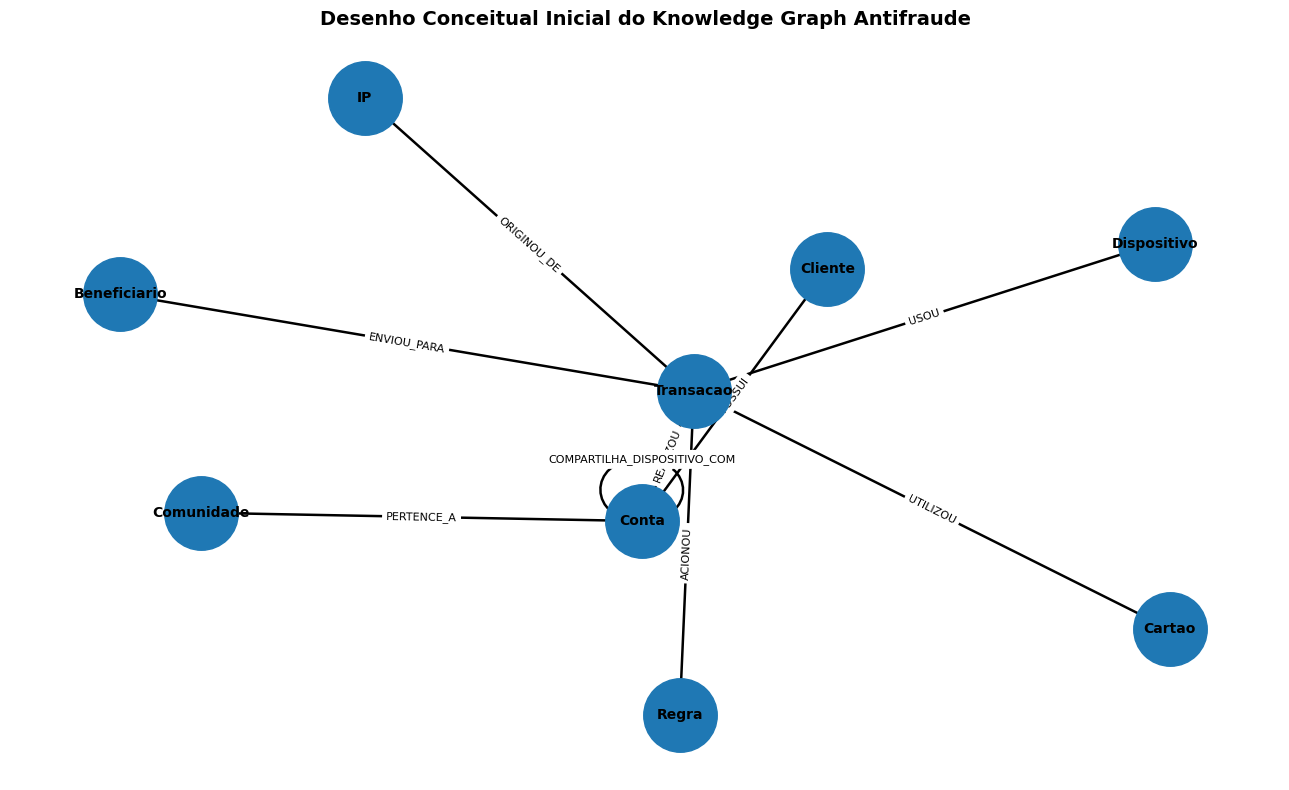

Figura salva em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\artifacts\figures\knowledge_graph_conceptual_model.png


In [9]:
G = nx.DiGraph()

nodes = [
    "Cliente",
    "Conta",
    "Transacao",
    "Beneficiario",
    "Dispositivo",
    "IP",
    "Cartao",
    "Regra",
    "Comunidade",
]

edges = [
    ("Cliente", "Conta", "POSSUI"),
    ("Conta", "Transacao", "REALIZOU"),
    ("Transacao", "Beneficiario", "ENVIOU_PARA"),
    ("Transacao", "Dispositivo", "USOU"),
    ("Transacao", "IP", "ORIGINOU_DE"),
    ("Transacao", "Cartao", "UTILIZOU"),
    ("Transacao", "Regra", "ACIONOU"),
    ("Conta", "Conta", "COMPARTILHA_DISPOSITIVO_COM"),
    ("Conta", "Comunidade", "PERTENCE_A"),
]

G.add_nodes_from(nodes)

for source, target, relation in edges:
    G.add_edge(source, target, label=relation)

plt.figure(figsize=(13, 8))

pos = nx.spring_layout(G, seed=42, k=1.2)

nx.draw_networkx_nodes(G, pos, node_size=2800)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Desenho Conceitual Inicial do Knowledge Graph Antifraude", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()

output_path = FIGURES_DIR / "knowledge_graph_conceptual_model.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Figura salva em: {output_path}")

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 9. Critérios de Sucesso do MVP</strong></font>

<font size="2" color='#66666'>

>- O MVP será considerado bem-sucedido se conseguir demonstrar, de forma clara e explicável, como técnicas de dados e grafos podem apoiar a prevenção a fraudes transacionais.

>- **Critérios técnicos**
    - Gerar dados sintéticos coerentes com o domínio de fraude.
    - Implementar regras antifraude interpretáveis.
    - Criar um modelo de grafo com entidades e relações relevantes.
    - Aplicar métricas de centralidade e detecção de comunidades.
    - Criar um score de risco transacional ou por conta.
    - Produzir explicações compreensíveis para os alertas.

>- **Critérios de negócio**
    - Identificar contas, dispositivos, beneficiários ou comunidades suspeitas.
    - Priorizar alertas para investigação.
    - Explicar por que uma transação ou conta foi considerada arriscada.
    - Demonstrar valor analítico para times de prevenção a fraudes.
    - Apresentar o projeto de forma executiva para portfólio e entrevistas.

>- **Critérios de portfólio**
    - README premium no GitHub.
    - Notebooks organizados em narrativa CRISP-DM+.
    - Visualizações executivas.
    - Página HTML no portfólio.
    - Possível dashboard Streamlit investigativo.

---

</font></div>

In [11]:
def dataframe_to_markdown_file(df: pd.DataFrame, title: str, path: Path) -> None:
    content = f"# {title}\n\n"
    content += df.to_markdown(index=False)
    content += "\n"
    path.write_text(content, encoding="utf-8")


dataframe_to_markdown_file(
    crisp_dm_plus,
    "Plano CRISP-DM+ — Fraud Graph Analytics",
    DOCS_DIR / "crisp_dm_plus_plan.md",
)

dataframe_to_markdown_file(
    ontology_entities,
    "Ontologia Inicial do Domínio Antifraude",
    DOCS_DIR / "ontology_entities.md",
)

dataframe_to_markdown_file(
    graph_relationships,
    "Modelo Inicial de Relações do Knowledge Graph",
    DOCS_DIR / "graph_relationships.md",
)

dataframe_to_markdown_file(
    business_glossary,
    "Business Language Model — Glossário Antifraude",
    DOCS_DIR / "business_glossary.md",
)

dataframe_to_markdown_file(
    fraud_taxonomy,
    "Taxonomia Inicial de Fraudes",
    DOCS_DIR / "fraud_taxonomy.md",
)

dataframe_to_markdown_file(
    investigative_hypotheses,
    "Hipóteses Investigativas Antifraude",
    DOCS_DIR / "investigative_hypotheses.md",
)

print("Artefatos exportados para a pasta docs:")
for file in sorted(DOCS_DIR.glob("*.md")):
    print(f"- {file.name}")

Artefatos exportados para a pasta docs:
- business_glossary.md
- crisp_dm_plus_plan.md
- estrategia.md
- fraud_rules_catalog.md
- fraud_taxonomy.md
- graph_data_model.md
- graph_relationships.md
- investigative_hypotheses.md
- ontology_entities.md


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 10. Conclusão Executiva do Notebook 00</strong></font>

<font size="2" color='#66666'>

>- Este notebook estabeleceu a fundação conceitual do projeto **Fraud Graph Analytics**, estruturando o domínio de prevenção a fraudes transacionais por meio de uma abordagem CRISP-DM+.

>- **Foram definidos:**
    - o contexto de negócio do problema;
    - a extensão CRISP-DM+ com Domain Understanding Semântico;
    - a ontologia inicial do domínio;
    - o Business Language Model;
    - a taxonomia de fraudes;
    - as hipóteses investigativas;
    - o desenho inicial do Knowledge Graph;
    - os critérios de sucesso técnico, analítico e executivo do MVP.

>- A partir desta base, o próximo passo será construir o **Notebook 01 — Generate Synthetic Transactions**, responsável por criar dados sintéticos coerentes com os cenários definidos neste notebook.

>- Esses dados serão utilizados posteriormente para:
    - análise exploratória;
    - motor de regras antifraude;
    - modelagem em grafo;
    - algoritmos de centralidade e comunidade;
    - score de risco explicável;
    - empacotamento executivo para portfólio.

---

</font></div>

In [8]:
%reload_ext watermark 
%watermark -a "Roberto-SSoares-LfLngLrnng" -d -t -u --iversions -v -m -h

Author: Roberto-SSoares-LfLngLrnng

Last updated: 2026-04-27 01:39:41

Python implementation: CPython
Python version       : 3.13.11
IPython version      : 9.13.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 158 Stepping 9, GenuineIntel
CPU cores   : 4
Architecture: 64bit

Hostname: PC-ROBERTO

matplotlib: 3.10.9
networkx  : 3.6.1
pandas    : 2.3.3



<div style="background-color:#f3f2ee">
    
<font size="6" color='#CC403E'><strong>Fim</strong></font>

<font size="3" color='#66666'></font></div>


In [9]:
#!uv pip install nbconvert -U -q
!jupyter nbconvert --to html --template-file my-template-html-v10.tpl 00_domain_understanding_crisp_dm_plus.ipynb

[NbConvertApp] Converting notebook 00_domain_understanding_crisp_dm_plus.ipynb to html
[NbConvertApp] Writing 159167 bytes to 00_domain_understanding_crisp_dm_plus.html
